In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from matplotlib.colors import ListedColormap




# ==========================================
# 2) ヘルパー関数
# ==========================================
def initialize_strategy_grid(n, init_coop=0.5):
    """
    n×n のグリッドを用意し、
    init_coop の確率で協力 (1) を割り当て、
    それ以外を背信 (0) とする。
    """
    rand_grid = np.random.rand(n, n)  # [0,1) の一様乱数
    strategy_grid = (rand_grid < init_coop).astype(int)
    return strategy_grid


def get_neighbor_coords_4(n, x, y):
    """
    上下左右4近傍（トーラス構造）を返す。
    """
    return [
        ((x - 1) % n, y),     # 上
        ((x + 1) % n, y),     # 下
        (x, (y - 1) % n),     # 左
        (x, (y + 1) % n),     # 右
    ]


def play_game(strategy_grid, b, c):
    """
    NetLogo の play-game 相当:
      - 各セルについて背信(0)/協力(1)を参照
      - 上下左右の協力者数 neighborsC と背信者数 neighborsD を数え、
        下記の式で利得 payoff を計算
         協力者なら: payoff = neighborsC * (b - c)  +  neighborsD * ( - c )
         背信者なら: payoff = neighborsC * b        +  neighborsD * 0
      - 計算結果を payoff_grid に格納して返す
    """
    n = strategy_grid.shape[0]
    payoff_grid = np.zeros((n, n), dtype=float)
    
    for x in range(n):
        for y in range(n):
            # 自分の戦略
            my_strategy = strategy_grid[x, y]
            
            # 近傍の協力者数・背信者数を数える
            neighbors = get_neighbor_coords_4(n, x, y)
            neighborsC = 0
            neighborsD = 0
            for (nx, ny) in neighbors:
                if strategy_grid[nx, ny] == 1:
                    neighborsC += 1
                else:
                    neighborsD += 1
            
            # 利得を計算
            if my_strategy == 1:
                # 協力者の場合
                payoff = neighborsC * (b - c) + neighborsD * (-c)
            else:
                # 背信者の場合
                payoff = neighborsC * b  # 背信者は協力者から b を得る
            
            payoff_grid[x, y] = payoff
    
    return payoff_grid


def evolve(strategy_grid, payoff_grid):
    """
    NetLogo の evolve 相当:
      - 各エージェントは近傍4マスのうち最も利得が高いエージェントを見つける
      - その近傍の戦略が自分より利得が高ければ模倣する
      - (同じ利得なら何もしない)
    """
    n = strategy_grid.shape[0]
    new_grid = strategy_grid.copy()
    
    for x in range(n):
        for y in range(n):
            my_payoff = payoff_grid[x, y]
            # 近傍を走査して最高利得のエージェントを探す
            neighbors = get_neighbor_coords_4(n, x, y)
            
            # 自分自身も "比較対象" に含める方針なら neighbors に (x, y) を追加
            # → NetLogo のコードだと、"max-one-of neighbors4" は自分を含めないので、
            #   ここでは近傍だけを見る
            best_payoff = my_payoff
            best_strategy = strategy_grid[x, y]
            
            for (nx, ny) in neighbors:
                if payoff_grid[nx, ny] > best_payoff:
                    best_payoff = payoff_grid[nx, ny]
                    best_strategy = strategy_grid[nx, ny]
            
            # もし近傍が自分より高利得なら、その戦略を模倣
            if best_payoff > my_payoff:
                new_grid[x, y] = best_strategy
    
    return new_grid


def step_one_round(strategy_grid, b, c):
    """
    1ステップ分:
      - play_game で payoff を計算
      - evolve で戦略を更新
    """
    payoff_grid = play_game(strategy_grid, b, c)
    new_grid = evolve(strategy_grid, payoff_grid)
    return new_grid


def all_same_strategy(strategy_grid):
    """
    全セルが同じ戦略(0または1)になっていれば True を返す。
    """
    return (strategy_grid.min() == strategy_grid.max())


# ==========================================
# 3) アニメーション作成
# ==========================================
def animate_cooperation_evolution(
    initial_grid, b, c, num_steps=200, interval=200
):
    """
    協力(青)・背信(赤)の進化をアニメーション表示
      - 各ステップで play_game -> evolve
      - 全て同じ戦略になったら途中で終了
    """
    # カラーマップ: 0=赤, 1=青
    # ListedColormap を使うと離散色を簡単に扱える
    cmap = ListedColormap(["red", "blue"])
    
    # 各ステップの戦略グリッドを保存
    grid_history = [initial_grid]
    
    # シミュレーションを実行
    current_grid = initial_grid
    for step in range(num_steps):
        next_grid = step_one_round(current_grid, b, c)
        grid_history.append(next_grid)
        current_grid = next_grid
        # もし全セルが同じ戦略になれば打ち切り
        if all_same_strategy(current_grid):
            break
    
    # ----- アニメ用セットアップ -----
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(grid_history[0], cmap=cmap, vmin=0, vmax=1)
    ax.set_title("Evolution of Cooperation (Blue) / Defection (Red)")
    ax.set_xticks([])
    ax.set_yticks([])
    
    # アップデート関数
    def update(frame):
        im.set_data(grid_history[frame])
        return [im]
    
    ani = animation.FuncAnimation(
        fig, update, frames=len(grid_history), interval=interval, blit=True
    )
    return HTML(ani.to_jshtml())



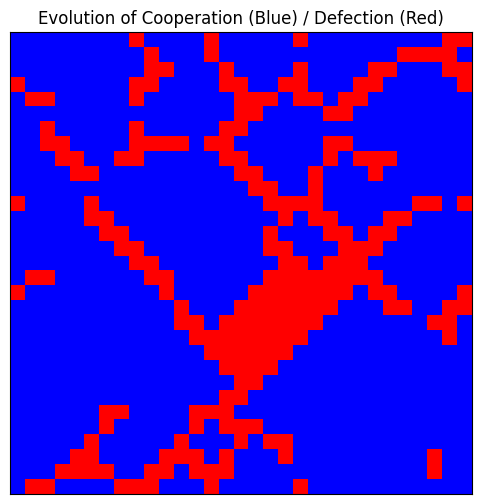

In [11]:

# ==========================================
# 1) パラメータ設定
# ==========================================
N = 31                # グリッドサイズ N×N
init_coop_freq = 0.5  # 初期協力者（strategy=1）の割合
payoff_benefit = 1.0  # b: 利得の「利益」(協力者同士のメリット)
payoff_cost   = 0.2   # c: 利得の「コスト」（協力が負担するコスト）
NUM_STEPS     = 200   # 最大シミュレーションステップ
INTERVAL      = 200   # アニメーション表示のインターバル（ミリ秒）

# ==========================================
# 4) メイン実行部
# ==========================================
if __name__ == "__main__":
    # 1) 初期グリッドの作成
    strategy_grid = initialize_strategy_grid(N, init_coop=init_coop_freq)
    
    # 2) アニメーションを作成
    HTML_obj = animate_cooperation_evolution(
        strategy_grid,
        b=payoff_benefit,
        c=payoff_cost,
        num_steps=NUM_STEPS,
        interval=INTERVAL
    )
    
    # 3) Jupyter/Google Colab 等で HTML_obj を表示するとアニメーションが再生されます
    #display(HTML_obj)


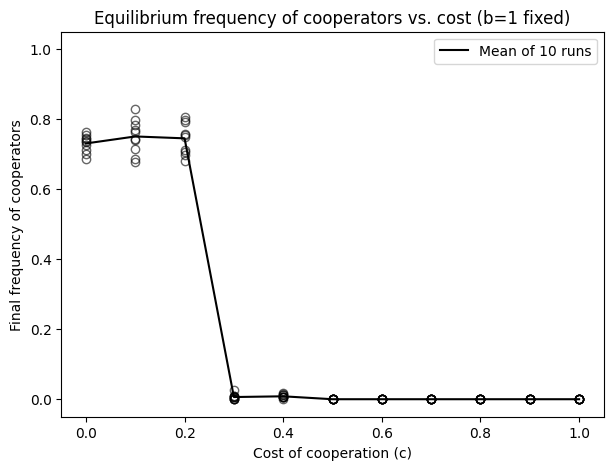

In [7]:
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.colors import ListedColormap

# ==========================
# シミュレーション部分
# ==========================

N = 31                # グリッドサイズ (N x N)
max_steps = 200       # 1回のシミュレーションの最大ステップ数
init_coop_freq = 0.5  # 初期協力者の割合
b = 1.0               # 利得の「利益」（NetLogoコード同様にb=1固定）



def run_simulation_once(n, init_coop, b, c, max_steps=200):
    """
    コスト c を与えて1回シミュレーションし、
    最終ステップでの協力率を返す。
    途中で全員同じ戦略になれば終了。
    """
    grid = initialize_strategy_grid(n, init_coop)
    for step in range(max_steps):
        payoff_grid = play_game(grid, b, c)
        new_grid = evolve(grid, payoff_grid)
        if np.all(new_grid == 1) or np.all(new_grid == 0):
            grid = new_grid
            break
        grid = new_grid
    
    # シミュレーション終了時点での協力率
    coop_fraction = np.mean(grid == 1)
    return coop_fraction

# ==========================
# コスト c を変えて繰り返し試行
# ==========================
c_values = np.arange(0.0, 1.01, 0.1)   # 0.0 ～ 1.0 を0.1刻み
num_runs_per_condition = 10           # 各コスト c に対して10回ずつ実行

all_results = []  # shape = (len(c_values), num_runs_per_condition)

for c in c_values:
    runs_result = []
    for _ in range(num_runs_per_condition):
        final_coop = run_simulation_once(N, init_coop_freq, b, c, max_steps)
        runs_result.append(final_coop)
    all_results.append(runs_result)

all_results = np.array(all_results)  # 2次元配列 (len(c_values), num_runs_per_condition)
means = all_results.mean(axis=1)     # 各 c に対する平均協力率

# ==========================
# グラフ描画
# ==========================
plt.figure(figsize=(7,5))

# 1) 個々の試行結果をプロット (open circles)
for i, c in enumerate(c_values):
    plt.plot(
        [c]*num_runs_per_condition,
        all_results[i], 
        marker='o', 
        linestyle='None', 
        fillstyle='none',  # 中が塗りつぶされない円
        color='black', 
        alpha=0.6
    )

# 2) 平均値を線でつなぐ (黒線)
plt.plot(c_values, means, '-k', label='Mean of 10 runs')

plt.xlabel('Cost of cooperation (c)')
plt.ylabel('Final frequency of cooperators')
plt.title('Equilibrium frequency of cooperators vs. cost (b=1 fixed)')
plt.ylim(-0.05, 1.05)
plt.legend(loc='best')
plt.show()


# Add randomness

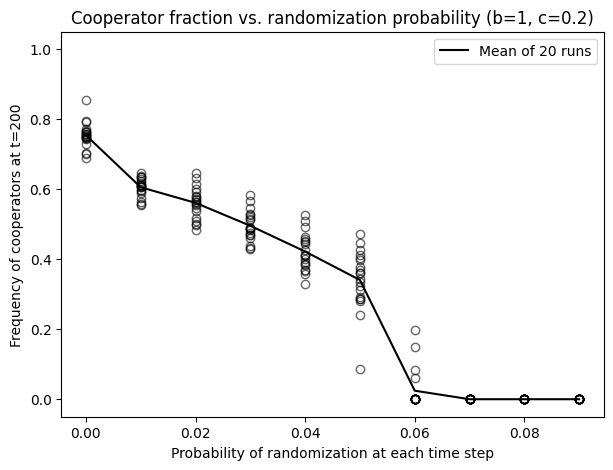

In [10]:
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.colors import ListedColormap

# ==========================
# 1) パラメータ設定
# ==========================
N = 31                  # グリッドサイズ (N x N)
MAX_STEPS = 200         # シミュレーションステップ数
INIT_COOP_FREQ = 0.5    # 初期協力率 (50%)
B = 1.0                 # 協力の利益 b
C = 0.2                 # 協力のコスト c

# -- グラフ用 --
NUM_RUNS_PER_CONDITION = 20    # 各 randomization_prob での繰り返し回数
R_VALUES = np.arange(0.0, 0.1, 0.01)  # 0.0～1.0 を0.1刻み (11通り)


# ==========================
# 2) ヘルパー関数
# ==========================

def initialize_strategy_grid(n, init_coop=0.5):
    """
    n×n のグリッドを用意し、init_coop の確率で協力(1), それ以外を背信(0).
    """
    rand_grid = np.random.rand(n, n)
    strategy_grid = (rand_grid < init_coop).astype(int)
    return strategy_grid

def get_neighbor_coords_4(n, x, y):
    """
    上下左右4近傍 (トーラス) を返す
    """
    return [
        ((x - 1) % n, y),
        ((x + 1) % n, y),
        (x, (y - 1) % n),
        (x, (y + 1) % n),
    ]

def play_game(strategy_grid, b, c):
    """
    各セル(x,y)の利得を計算して payoff_grid に格納。
      - 協力者(1) => payoff = neighborsC*(b-c) + neighborsD*(-c)
      - 背信者(0) => payoff = neighborsC*b
    """
    n = strategy_grid.shape[0]
    payoff_grid = np.zeros((n, n), dtype=float)
    
    for x in range(n):
        for y in range(n):
            my_strategy = strategy_grid[x, y]
            neighbors = get_neighbor_coords_4(n, x, y)
            neighborsC = sum(strategy_grid[nx, ny] for (nx, ny) in neighbors)
            neighborsD = 4 - neighborsC
            if my_strategy == 1:
                # 協力者
                payoff = neighborsC*(b - c) + neighborsD*(-c)
            else:
                # 背信者
                payoff = neighborsC*b
            payoff_grid[x, y] = payoff
    
    return payoff_grid

def evolve(strategy_grid, payoff_grid):
    """
    NetLogo の evolve と同様:
      - 各セル(x,y)が近傍4マスの利得を確認し、最も利得の高い個体を見つける
      - もしその利得が自分より高ければ、その戦略に模倣する
    """
    n = strategy_grid.shape[0]
    new_grid = strategy_grid.copy()
    for x in range(n):
        for y in range(n):
            my_payoff = payoff_grid[x, y]
            neighbors = get_neighbor_coords_4(n, x, y)
            best_payoff = my_payoff
            best_strategy = strategy_grid[x, y]
            for (nx, ny) in neighbors:
                if payoff_grid[nx, ny] > best_payoff:
                    best_payoff = payoff_grid[nx, ny]
                    best_strategy = strategy_grid[nx, ny]
            if best_payoff > my_payoff:
                new_grid[x, y] = best_strategy
    return new_grid

def randomize_locations(strategy_grid, randomization_prob):
    """
    ランダム化処理 (NetLogo の 'randomize-locations' 相当)
    各セル(x,y)に対して:
      - random.random() < randomization_prob なら
        - ランダムに別のセル(nx, ny)を選び、戦略をスワップ
    ※単純化のため、同じセルを二度選ぶ場合もあり得ます。
    """
    n = strategy_grid.shape[0]
    coords = [(x, y) for x in range(n) for y in range(n)]
    random.shuffle(coords)  # ランダム順に処理
    
    for (x, y) in coords:
        if random.random() < randomization_prob:
            # 自分以外からランダム選択
            nx, ny = random.choice(coords)
            while (nx, ny) == (x, y):
                nx, ny = random.choice(coords)
            # スワップ
            tmp = strategy_grid[x, y]
            strategy_grid[x, y] = strategy_grid[nx, ny]
            strategy_grid[nx, ny] = tmp

def run_simulation_once(n, b, c, randomization_prob, max_steps=200, init_coop=0.5):
    """
    1回分のシミュレーション:
      - 初期化
      - 各ステップで
         1) randomize_locations (確率 randomization_prob)
         2) play_game -> evolve
      - 最終ステップ( t=200 )での協力率を返す
    """
    grid = initialize_strategy_grid(n, init_coop)
    
    for step in range(max_steps):
        # 1) ランダムな位置交換
        randomize_locations(grid, randomization_prob)
        
        # 2) 利得計算 -> 戦略更新
        payoff_grid = play_game(grid, b, c)
        new_grid = evolve(grid, payoff_grid)
        grid = new_grid
    
    # シミュレーション終了時点( t=200 )での協力率
    coop_fraction = np.mean(grid == 1)
    return coop_fraction


# ==========================
# 3) 各 randomization_prob について 20回ずつ試行し、グラフ化
# ==========================
if __name__ == "__main__":
    # R_VALUES = [0.0, 0.1, 0.2, ..., 1.0] 
    all_results = []  # (len(R_VALUES), NUM_RUNS_PER_CONDITION)
    
    for r_prob in R_VALUES:
        runs = []
        for _ in range(NUM_RUNS_PER_CONDITION):
            final_coop = run_simulation_once(
                n=N,
                b=B,
                c=C,
                randomization_prob=r_prob,
                max_steps=MAX_STEPS,
                init_coop=INIT_COOP_FREQ
            )
            runs.append(final_coop)
        all_results.append(runs)
    
    all_results = np.array(all_results)
    means = all_results.mean(axis=1)
    
    # --- グラフ描画 ---
    plt.figure(figsize=(7,5))
    
    # 個々の試行結果 (open circles)
    for i, r_prob in enumerate(R_VALUES):
        plt.plot([r_prob]*NUM_RUNS_PER_CONDITION,
                 all_results[i],
                 marker='o',
                 linestyle='None',
                 fillstyle='none',   # 中を塗りつぶさない
                 color='black',
                 alpha=0.6
                )
    
    # 平均値を線でつなぐ (黒線)
    plt.plot(R_VALUES, means, '-k', label='Mean of 20 runs')
    
    # 軸ラベルなど
    plt.xlabel('Probability of randomization at each time step')
    plt.ylabel('Frequency of cooperators at t=200')
    plt.ylim(-0.05, 1.05)
    plt.title('Cooperator fraction vs. randomization probability (b=1, c=0.2)')
    plt.legend(loc='best')
    plt.show()
